# This is a workflow to query and visualize FIRMS (real-time fire) data.

Below, please enter your map key to gain access to the API. You can get one <span style='color:blue'>[here](https://firms.modaps.eosdis.nasa.gov/api/map_key/)</span>

In [2]:
import pandas as pd
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(0,"/home/jovyan/shared/Libraries")
import victor

MAP_KEY = 'adedf1a21791fe0e126299ba9dab98f0'

### For reference, we display the various satellites and their accessible date ranges.

In [3]:
da_url = 'https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/' + MAP_KEY + '/all'
df = pd.read_csv(da_url)
display(df)

area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + MAP_KEY + '/VIIRS_NOAA20_NRT/54,5.5,102,40/3'
df_area = pd.read_csv(area_url)
df_area

,data_id,min_date,max_date
0,MODIS_NRT,2025-02-01,2025-05-22
1,MODIS_SP,2000-11-01,2025-01-31
2,VIIRS_NOAA20_NRT,2025-02-01,2025-05-22
3,VIIRS_NOAA20_SP,2018-04-01,2025-01-31
4,VIIRS_NOAA21_NRT,2024-01-17,2025-05-22
5,VIIRS_SNPP_NRT,2025-02-01,2025-05-22
6,VIIRS_SNPP_SP,2012-01-20,2025-01-31
7,LANDSAT_NRT,2022-06-20,2025-05-22
8,GOES_NRT,2022-08-09,2025-05-22
9,BA_MODIS,2000-11-01,2025-02-01


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,11.92436,99.00312,344.91,0.49,0.48,2025-05-20,614,N20,VIIRS,n,2.0NRT,292.75,7.48,D
1,12.18171,99.05191,339.44,0.48,0.48,2025-05-20,614,N20,VIIRS,n,2.0NRT,294.12,9.08,D
2,12.18259,99.05225,340.01,0.48,0.48,2025-05-20,614,N20,VIIRS,n,2.0NRT,294.28,8.98,D
3,12.22675,98.86871,339.35,0.49,0.49,2025-05-20,614,N20,VIIRS,n,2.0NRT,292.33,5.81,D
4,12.37808,99.03531,337.88,0.47,0.48,2025-05-20,614,N20,VIIRS,n,2.0NRT,293.24,4.03,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4534,35.33229,71.70244,336.22,0.51,0.66,2025-05-22,907,N20,VIIRS,n,2.0NRT,310.25,7.41,D
4535,35.33785,71.70402,367.00,0.51,0.66,2025-05-22,907,N20,VIIRS,h,2.0NRT,315.06,8.15,D
4536,35.33809,71.70921,339.04,0.51,0.66,2025-05-22,907,N20,VIIRS,n,2.0NRT,307.07,8.15,D
4537,35.33855,71.70605,367.00,0.51,0.66,2025-05-22,907,N20,VIIRS,h,2.0NRT,310.29,7.41,D


### Now, a few simple values are required to get the data.

In [4]:
# Bounds: Enter in the format min_long, max_long, min_lat, mat_lat
bounds = [54,102,5.5,40]

# Number of days previous to poll
days = 3

# Start date - YYYY-MM-DD format. Leave as none to start from current day
date = None

In [5]:
data = victor.get_firms_data(MAP_KEY, bounds, days, date)

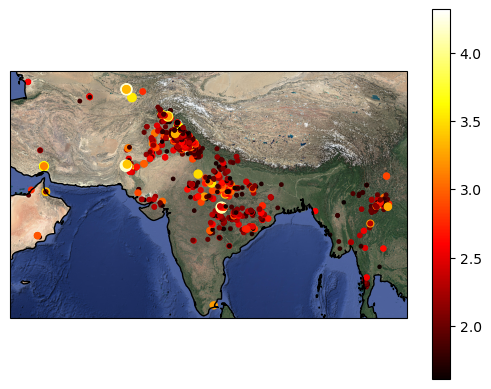

In [6]:
ax = plt.axes(projection=ccrs.PlateCarree())
google_terrain = cimgt.GoogleTiles(style="satellite")
ax.coastlines()
ax.add_image(google_terrain,8)
plt.scatter(data.longitude,data.latitude, data.frp, c=np.log(data.frp),cmap="hot")
plt.colorbar()
plt.show()

In [27]:
from datetime import datetime
import datetime as dt
today = datetime.now()
asf = today-datetime.strptime(day, "%Y-%m-%d") for day in data.acq_date

SyntaxError: invalid syntax (2657432807.py, line 4)

In [23]:
asf = today-datetime.strptime(data.acq_date[0], "%Y-%m-%d")

In [30]:
data.acq_date[1]

'2025-05-20'

In [31]:
print(day for day in data.acq_date)

<generator object <genexpr> at 0x7f84e4babae0>
